<a href="https://colab.research.google.com/github/25wh1a0511/NASSCOM/blob/main/U6_Probability_Statistics_Part1_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)

df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()


Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)


total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [4]:
print('Mean total_bill:', round(df['total_bill'].mean(), 2))

# Categorical -> counts / mode make sense (mean would be meaningless)
print('Day value counts:')
print(df['day'].value_counts())


Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [5]:
# 1. Numerical vs categorical columns
# YOUR CODE HERE
print(df.dtypes)

numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

# 2. Mean of a numerical column (tip)
# YOUR CODE HERE
print('Mean tip:', round(df['tip'].mean(), 2))

# 3. Value counts of a categorical column (sex)
# YOUR CODE HERE
print('Sex value counts:')
print(df['sex'].value_counts())

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']
Mean tip: 3.0
Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


In [6]:
col = df['total_bill']
print('Mean   :', round(col.mean(), 2))    # average; sensitive to outliers
print('Median :', round(col.median(), 2))  # middle value; robust to outliers
print('Mode   :', round(col.mode()[0], 2)) # most frequent value

Mean   : 19.79
Median : 17.8
Mode   : 13.42


mean > median ? True -> right-skewed


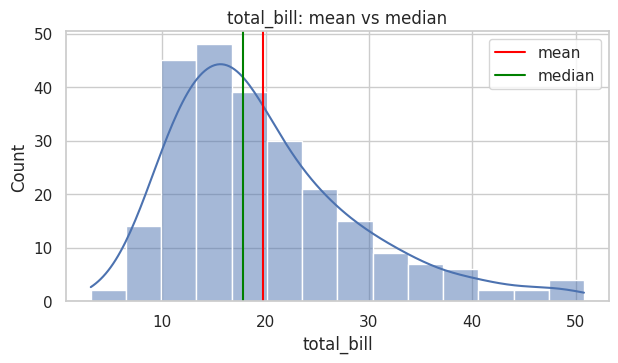

In [41]:
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True )
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean: 2.99827868852459
Median: 2.9
Mode: 2.0
Is right-skewed? True


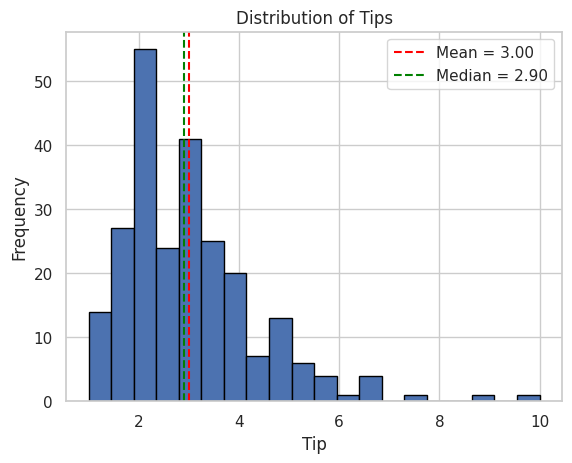

In [39]:
tip = df['tip']

# 1. mean, median, mode
mean_tip = tip.mean()
median_tip = tip.median()
mode_tip = tip.mode()[0]

print("Mean:", mean_tip)
print("Median:", median_tip)
print("Mode:", mode_tip)

# 2. mean > median ?
print("Is right-skewed?", mean_tip > median_tip)

# 3. histogram with mean & median lines
import matplotlib.pyplot as plt

plt.hist(tip, bins=20, edgecolor='black')
plt.axvline(mean_tip, color='red', linestyle='--', label=f'Mean = {mean_tip:.2f}')
plt.axvline(median_tip, color='green', linestyle='--', label=f'Median = {median_tip:.2f}')

plt.xlabel('Tip')
plt.ylabel('Frequency')
plt.title('Distribution of Tips')
plt.legend()
plt.show()


In [10]:
col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))


Range : 47.74
Var   : 79.25
Std   : 8.9


In [11]:
q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [12]:
tip = df['tip']

# 1. range, variance, std
# YOUR CODE HERE
range_tip = tip.max() - tip.min()
variance_tip = tip.var()
std_tip = tip.std()

print("Range:", range_tip)
print("Variance:", variance_tip)
print("Standard Deviation:", std_tip)

# 2. Q1, Q3, IQR
# YOUR CODE HERE
q1_tip = tip.quantile(0.25)
q3_tip = tip.quantile(0.75)
iqr_tip = q3_tip - q1_tip

print("Q1:", q1_tip)
print("Q3:", q3_tip)
print("IQR:", iqr_tip)


# 3. Most robust measure of spread = ?   (write your answer here)
print("Most robust measure of spread:", iqr_tip)


Range: 9.0
Variance: 1.9144546380624725
Standard Deviation: 1.3836381890011826
Q1: 2.0
Q3: 3.5625
IQR: 1.5625
Most robust measure of spread: 1.5625


In [13]:
col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)


print('\nSkewness:', round(col.skew(), 3))


min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


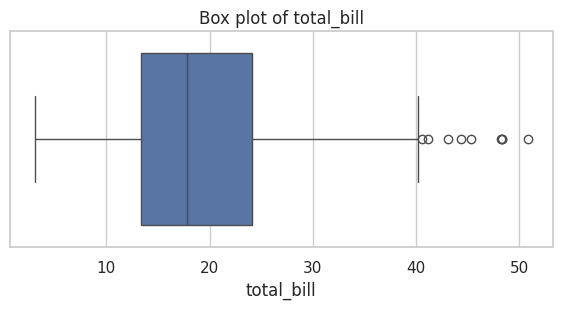

In [14]:
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()


Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


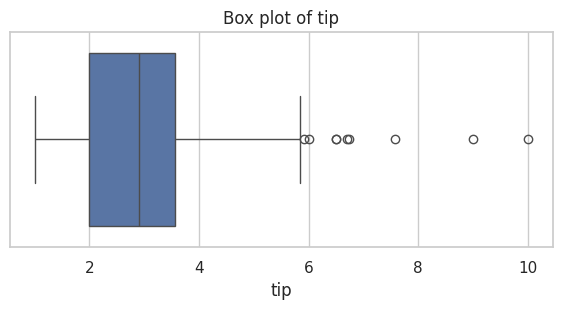

In [22]:
tip = df['tip']

# 1. five-number summary
# YOUR CODE HERE
print('Five-number summary:')
five = tip.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

# 2. skewness (+ comment on the direction of the lean)
# YOUR CODE HERE
print('\nSkewness:', round(tip.skew(), 3))

# 3. box plot of tip
# YOUR CODE HERE
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['tip'])
plt.title('Box plot of tip'); plt.show()

In [16]:
corr = df.corr(numeric_only=True)
print(corr.round(2))

print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


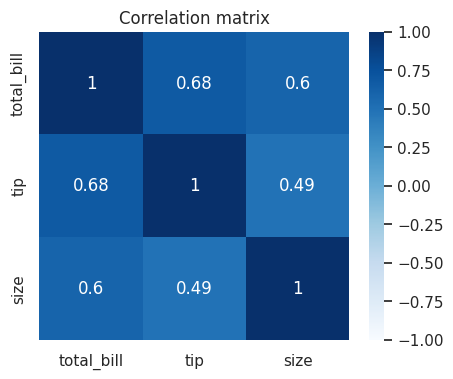

In [20]:
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [19]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


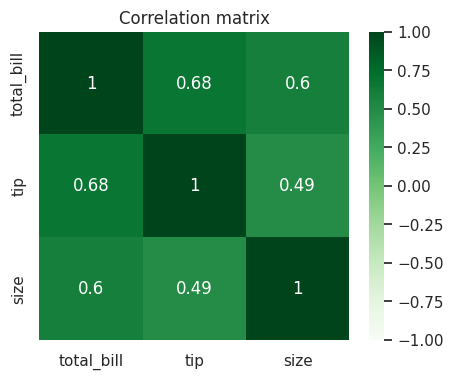

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [36]:
# 1. correlation matrix (rounded)
# YOUR CODE HERE
print(df.corr(numeric_only=True).round(2))

# 2. heatmap of the correlation matrix
# YOUR CODE HERE
plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Greens', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

# 3. df.describe() + 3 insights as comments
# YOUR CODE HERE
print(df.describe())
# Insight 1: ...
# Insight 2: ...
# Insight 3: ...